In [1]:
import torch
from torch import nn, optim
import numpy as np
import requests, gzip, os, hashlib, numpy
import matplotlib.pyplot as plt

In [2]:
def fetch(url):
    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())
    if os.path.isfile(fp):
        with open(fp, "rb") as f:
            dat = f.read()
    else:
        with open(fp, "wb") as f:
            dat = requests.get(url).content
            f.write(dat)
    return np.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()
X_train = fetch("http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz")[0x10:].reshape((-1, 28, 28))
Y_train = fetch("http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz")[8:]
X_test = fetch("http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz")[0x10:].reshape((-1, 28, 28))
Y_test = fetch("http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz")[8:]

In [3]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train)
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test)


(<matplotlib.image.AxesImage at 0x7f5f6d8947c0>, tensor(0, dtype=torch.uint8))

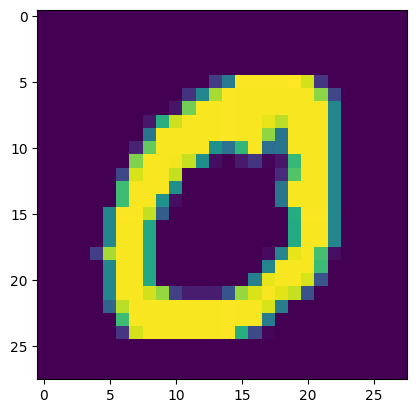

In [5]:
plt.imshow(X_train[51]),Y_train[51]

In [11]:
class ModelOne(torch.nn.Module):
    def __init__(self):
        super(ModelOne, self).__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = nn.functional.relu(self.layer1(x))
        x = nn.functional.relu(self.layer2(x))
        x = nn.functional.log_softmax(self.layer3(x), dim=1)
        
        return x
        

In [12]:
class ModelTwo(torch.nn.Module):
    def __init__(self):
        super(ModelTwo, self).__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = nn.functional.relu(self.layer1(x))
        x = nn.functional.log_softmax(self.layer2(x), dim=1)
        
        return x
        

In [32]:
one = ModelOne()
two = ModelTwo()

loss_function = nn.CrossEntropyLoss()
optimizerOne = optim.SGD(one.parameters(), lr=0.01)
optimizerTwo = optim.SGD(two.parameters(), lr=0.01)

In [33]:
# first model
for i in range(20):
    optimizerOne.zero_grad()
    y_hat = one(X_train.view(-1, 784))
    
    loss = loss_function(y_hat,Y_train)
    loss.backward()
    optimizerOne.step()
    
    print(f'{str(i)}: loss: {loss.item()}')

0: loss: 7.890341281890869
1: loss: 6.576857089996338
2: loss: 28.48988914489746
3: loss: 108.79861450195312
4: loss: 50.177490234375
5: loss: 61.670955657958984
6: loss: 65.53438568115234
7: loss: 9.306918144226074
8: loss: 4.735200881958008
9: loss: 2.260352611541748
10: loss: 2.147120475769043
11: loss: 2.0970888137817383
12: loss: 2.0576860904693604
13: loss: 2.0254781246185303
14: loss: 1.99837064743042
15: loss: 1.9832180738449097
16: loss: 1.9533494710922241
17: loss: 1.951609492301941
18: loss: 1.9011132717132568
19: loss: 1.8832495212554932


In [34]:
# second model
for i in range(20):
    optimizerTwo.zero_grad()
    y_hat = two(X_train.view(-1, 784))
    
    loss = loss_function(y_hat,Y_train)
    loss.backward()
    optimizerTwo.step()
    
    print(f'{str(i)}: loss: {loss.item()}')

0: loss: 30.14704704284668
1: loss: 278.8454284667969
2: loss: 1610.4725341796875
3: loss: 272.0224304199219
4: loss: 529.4349365234375
5: loss: 723.5655517578125
6: loss: 470.47467041015625
7: loss: 183.75856018066406
8: loss: 2.297459602355957
9: loss: 2.1384944915771484
10: loss: 2.0520377159118652
11: loss: 1.9959309101104736
12: loss: 1.953254222869873
13: loss: 1.8887215852737427
14: loss: 1.808292269706726
15: loss: 1.7244749069213867
16: loss: 1.6803303956985474
17: loss: 1.6950315237045288
18: loss: 1.6933218240737915
19: loss: 1.6357704401016235
